In [78]:
import joblib
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor

seed = 2

In [62]:
path = "C:/Users/A2xau/Downloads/calenviroscreen40resultsdatadictionary_F_2021 - GOOD dataset.csv"
data = pd.read_csv(path)

In [63]:
y_tox = data["Tox. Release"]
y_lbw = data["Low Birth Weight"]

X = data.drop(columns=[
    "Tox. Release",
    "Asthma",
    "Cardiovascular Disease",
    "Low Birth Weight"
])

In [64]:
# ---- y variables ----
y_tox = data["Tox. Release"]
y_lbw = data["Low Birth Weight"]

# ---- X features (shared for both models) ----
X = data.drop(columns=[
    "Tox. Release",
    "Asthma",
    "Cardiovascular Disease",
    "Low Birth Weight"
])

# =========================
# 🔹 SINGLE TRAIN/TEST SPLIT FOR X
# =========================
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=seed
)

# =========================
# 🔹 SPLIT y VARIABLES USING SAME INDICES
# =========================
y_train_tox = y_tox.loc[X_train.index]
y_test_tox  = y_tox.loc[X_test.index]

y_train_lbw = y_lbw.loc[X_train.index]
y_test_lbw  = y_lbw.loc[X_test.index]

# =========================
# 🔹 SCALE X ONCE (SHARED FEATURES)
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [65]:
# =========================
# 🔹 RIDGE REGRESSION (better than LinearRegression)
# =========================
ridge_tox = Ridge(alpha=1.0)
ridge_lbw = Ridge(alpha=1.0)

ridge_tox.fit(X_train_scaled, y_train_tox)
ridge_lbw.fit(X_train_scaled, y_train_lbw)

tox_pred_ridge = ridge_tox.predict(X_test_scaled)
lbw_pred_ridge = ridge_lbw.predict(X_test_scaled)

print("===== RIDGE REGRESSION =====")
print(f"Tox R2: {r2_score(y_test_tox, tox_pred_ridge):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_tox, tox_pred_ridge)):.4f}")
print(f"LBW R2: {r2_score(y_test_lbw, lbw_pred_ridge):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_lbw, lbw_pred_ridge)):.4f}")

===== RIDGE REGRESSION =====
Tox R2: 0.1441 | RMSE: 4101.6713
LBW R2: 0.0923 | RMSE: 1.5148


In [66]:
# =========================
# 🔹 POLYNOMIAL RIDGE (captures nonlinear interactions)
# =========================
poly_tox = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=1.0)
)

poly_lbw = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    Ridge(alpha=1.0)
)

poly_tox.fit(X_train_scaled, y_train_tox)
poly_lbw.fit(X_train_scaled, y_train_lbw)

tox_pred_poly = poly_tox.predict(X_test_scaled)
lbw_pred_poly = poly_lbw.predict(X_test_scaled)

print("\n===== POLYNOMIAL RIDGE =====")
print(f"Tox R2: {r2_score(y_test_tox, tox_pred_poly):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_tox, tox_pred_poly)):.4f}")
print(f"LBW R2: {r2_score(y_test_lbw, lbw_pred_poly):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_lbw, lbw_pred_poly)):.4f}")


===== POLYNOMIAL RIDGE =====
Tox R2: 0.2920 | RMSE: 3730.4780
LBW R2: 0.0978 | RMSE: 1.5103


In [67]:
# =========================
# 🔹 LINEAR REGRESSION MODELS
# =========================
lin_tox = LinearRegression()
lin_lbw = LinearRegression()

lin_tox.fit(X_train_scaled, y_train_tox)
lin_lbw.fit(X_train_scaled, y_train_lbw)

# Predictions
tox_pred_lin = lin_tox.predict(X_test_scaled)
lbw_pred_lin = lin_lbw.predict(X_test_scaled)

# Metrics
print("===== LINEAR REGRESSION =====")

print(f"Tox R2: {r2_score(y_test_tox, tox_pred_lin):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_tox, tox_pred_lin)):.4f}")
print(f"LBW R2: {r2_score(y_test_lbw, lbw_pred_lin):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_lbw, lbw_pred_lin)):.4f}")

===== LINEAR REGRESSION =====
Tox R2: 0.1441 | RMSE: 4101.6739
LBW R2: 0.0923 | RMSE: 1.5148


In [68]:
# =========================
# 🔹 RANDOM FOREST REGRESSOR (NEW 🔥)
# =========================
rf_tox = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=seed,
    n_jobs=-1
)

rf_lbw = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    random_state=seed,
    n_jobs=-1
)

rf_tox.fit(X_train_scaled, y_train_tox)
rf_lbw.fit(X_train_scaled, y_train_lbw)

tox_pred_rf = rf_tox.predict(X_test_scaled)
lbw_pred_rf = rf_lbw.predict(X_test_scaled)

print("\n===== RANDOM FOREST =====")
print(f"Tox R2: {r2_score(y_test_tox, tox_pred_rf):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_tox, tox_pred_rf)):.4f}")
print(f"LBW R2: {r2_score(y_test_lbw, lbw_pred_rf):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_lbw, lbw_pred_rf)):.4f}")



===== RANDOM FOREST =====
Tox R2: 0.5181 | RMSE: 3077.7843
LBW R2: 0.1941 | RMSE: 1.4274


In [69]:
# =========================
# 🔹 NEURAL NETWORK MODELS (IMPROVED)
# =========================
nn_tox = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=3000,
    random_state=seed
)

nn_lbw = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=3000,
    random_state=seed
)

nn_tox.fit(X_train_scaled, y_train_tox)
nn_lbw.fit(X_train_scaled, y_train_lbw)

tox_pred_nn = nn_tox.predict(X_test_scaled)
lbw_pred_nn = nn_lbw.predict(X_test_scaled)

print("\n===== NEURAL NETWORK (IMPROVED) =====")
print(f"Tox R2: {r2_score(y_test_tox, tox_pred_nn):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_tox, tox_pred_nn)):.4f}")
print(f"LBW R2: {r2_score(y_test_lbw, lbw_pred_nn):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_lbw, lbw_pred_nn)):.4f}")


===== NEURAL NETWORK (IMPROVED) =====
Tox R2: 0.5579 | RMSE: 2947.6687
LBW R2: -0.0997 | RMSE: 1.6674


In [70]:
cols = [
    "Tox. Release",
    "Asthma",
    "Cardiovascular Disease",
    "Low Birth Weight"
]

def custom_summary(df, cols):
    summary = pd.DataFrame({
        "count": df[cols].count(),
        "Min": df[cols].min(),
        "1st Qu.": df[cols].quantile(0.25),
        "Median": df[cols].median(),
        "Mean": df[cols].mean(),
        "3rd Qu.": df[cols].quantile(0.75),
        "Max": df[cols].max()
    })

    return summary

summary_table = custom_summary(data, cols).round(3)

# Prevent line wrapping in output
pd.set_option('display.expand_frame_repr', False)

print(summary_table)

print("\n7783 Data Points")

                        count   Min  1st Qu.  Median      Mean  3rd Qu.       Max
Tox. Release             7783  0.00  118.205  466.99  1615.283  1643.26  96985.63
Asthma                   7783  4.66   30.465   46.15    52.358    65.99    243.29
Cardiovascular Disease   7783  2.86    9.510   12.50    13.456    16.79     40.85
Low Birth Weight         7783  0.00    3.930    4.92     5.004     6.00     13.71

7783 Data Points


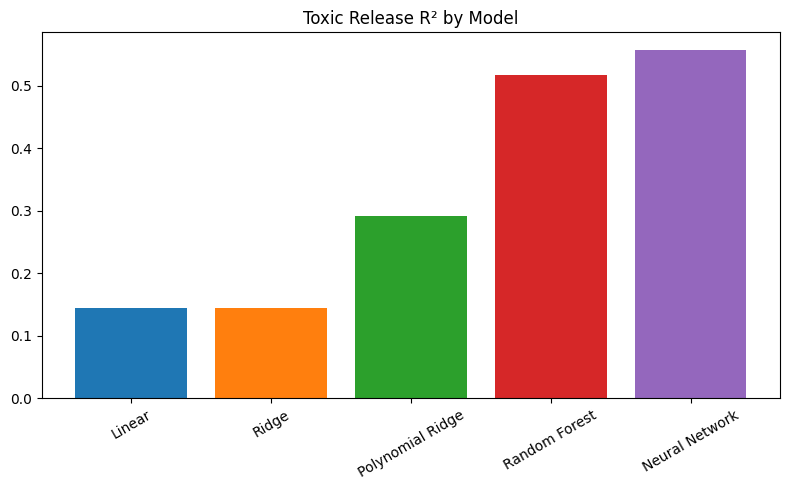

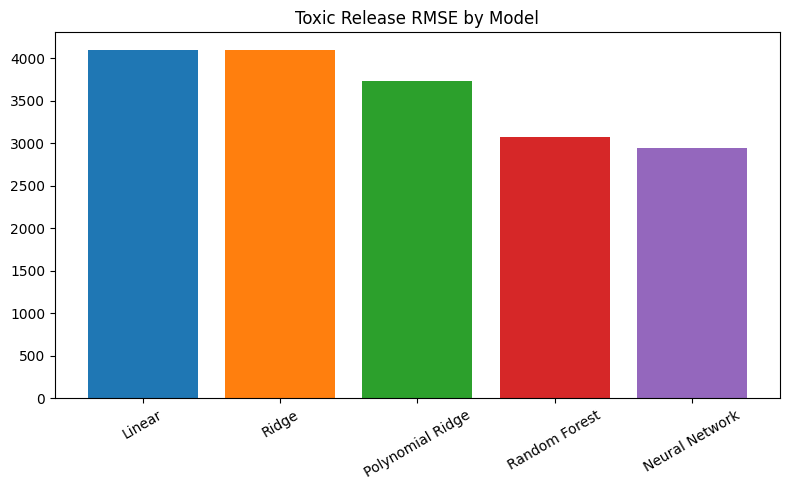

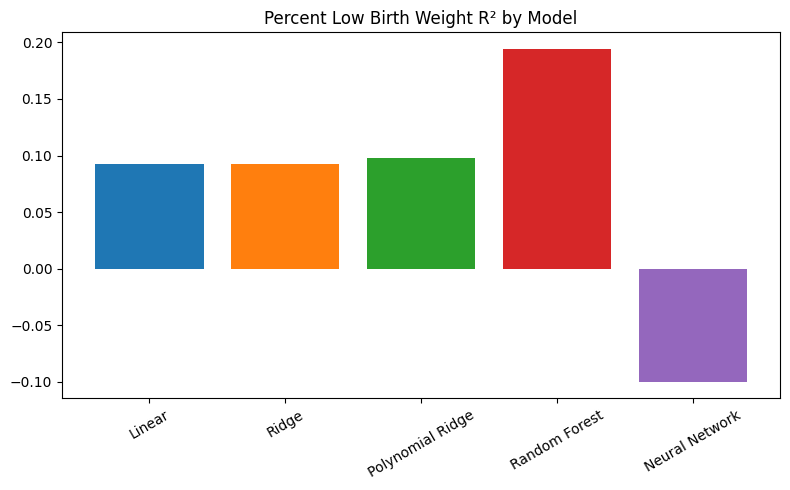

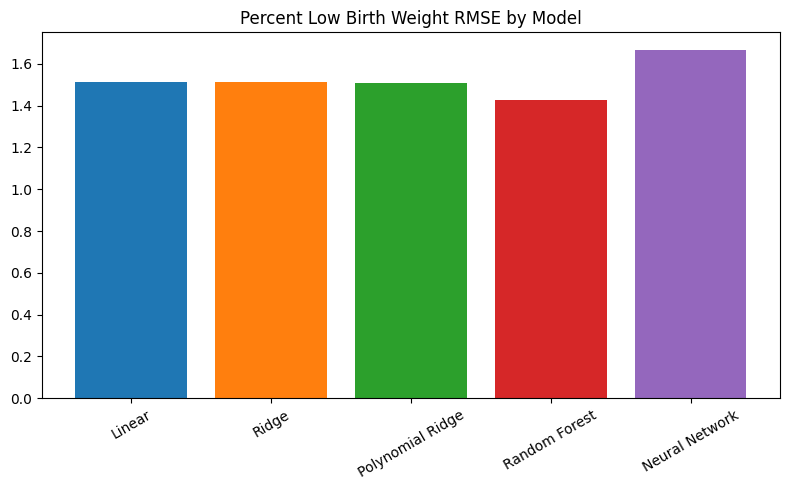

In [76]:
models = ["Linear", "Ridge", "Polynomial Ridge", "Random Forest", "Neural Network"]
x = np.arange(len(models))

# --- TOX ---
tox_r2 =    [0.1441, 0.1441, 0.2920, 0.5181, 0.5579]
tox_rmse =  [4102, 4102, 3730, 3078, 2948]

# --- LBW ---
lbw_r2 =    [0.0923, 0.0923, 0.0978, 0.1941, -0.0997]
lbw_rmse =  [1.5148, 1.5148, 1.5103, 1.4274, 1.6674]

# Get default Matplotlib color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


# =========================
# 🔹 TOX R²
# =========================
plt.figure(figsize=(8,5))
for i in range(len(models)):
    plt.bar(models[i], tox_r2[i], color=colors[i % len(colors)])

plt.title("Toxic Release R² by Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# =========================
# 🔹 TOX RMSE
# =========================
plt.figure(figsize=(8,5))
for i in range(len(models)):
    plt.bar(models[i], tox_rmse[i], color=colors[i % len(colors)])

plt.title("Toxic Release RMSE by Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# =========================
# 🔹 LBW R²
# =========================
plt.figure(figsize=(8,5))
for i in range(len(models)):
    plt.bar(models[i], lbw_r2[i], color=colors[i % len(colors)])

plt.title("Percent Low Birth Weight R² by Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# =========================
# 🔹 LBW RMSE
# =========================
plt.figure(figsize=(8,5))
for i in range(len(models)):
    plt.bar(models[i], lbw_rmse[i], color=colors[i % len(colors)])

plt.title("Percent Low Birth Weight RMSE by Model")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [77]:
joblib.dump(nn_tox, "NeuralNetwork.pkl")

NameError: name 'joblib' is not defined